# Task 1: Time Series Analysis and Forecasting

**Dataset:** Synthetic time series — 365 days of historical data + 60 days of held-out test data  
**Components:** Linear trend · Weekly (7-day) seasonality · Gaussian noise  
**Objective:** Decompose the series and forecast 60 days ahead using Moving Average, SES, and ARIMA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

---
## 1. Data Generation and Visualisation

In [2]:
# ── Generate 425 days (365 train + 60 test) ──────────────────────────────────
TOTAL_DAYS = 425
TRAIN_DAYS = 365
TEST_DAYS  = 60

t = np.arange(TOTAL_DAYS)
dates = pd.date_range(start='2023-01-01', periods=TOTAL_DAYS, freq='D')

# Components
trend      = 0.15 * t                              # linear upward trend
seasonality = 10 * np.sin(2 * np.pi * t / 7)      # weekly (7-day) sine wave
noise       = np.random.normal(loc=0, scale=3, size=TOTAL_DAYS)  # Gaussian noise

values = trend + seasonality + noise

ts = pd.Series(values, index=dates, name='value')
train = ts.iloc[:TRAIN_DAYS]
test  = ts.iloc[TRAIN_DAYS:]

print(f"Full series : {len(ts)} days  ({ts.index[0].date()} → {ts.index[-1].date()})")
print(f"Training set: {len(train)} days")
print(f"Test set    : {len(test)} days")
print(f"\nDescriptive statistics (training):")
print(train.describe().round(2))

Full series : 425 days  (2023-01-01 → 2024-02-29)
Training set: 365 days
Test set    : 60 days

Descriptive statistics (training):
count    365.00
mean      27.33
std       17.62
min      -11.61
25%       13.31
50%       26.75
75%       42.74
max       65.12
Name: value, dtype: float64


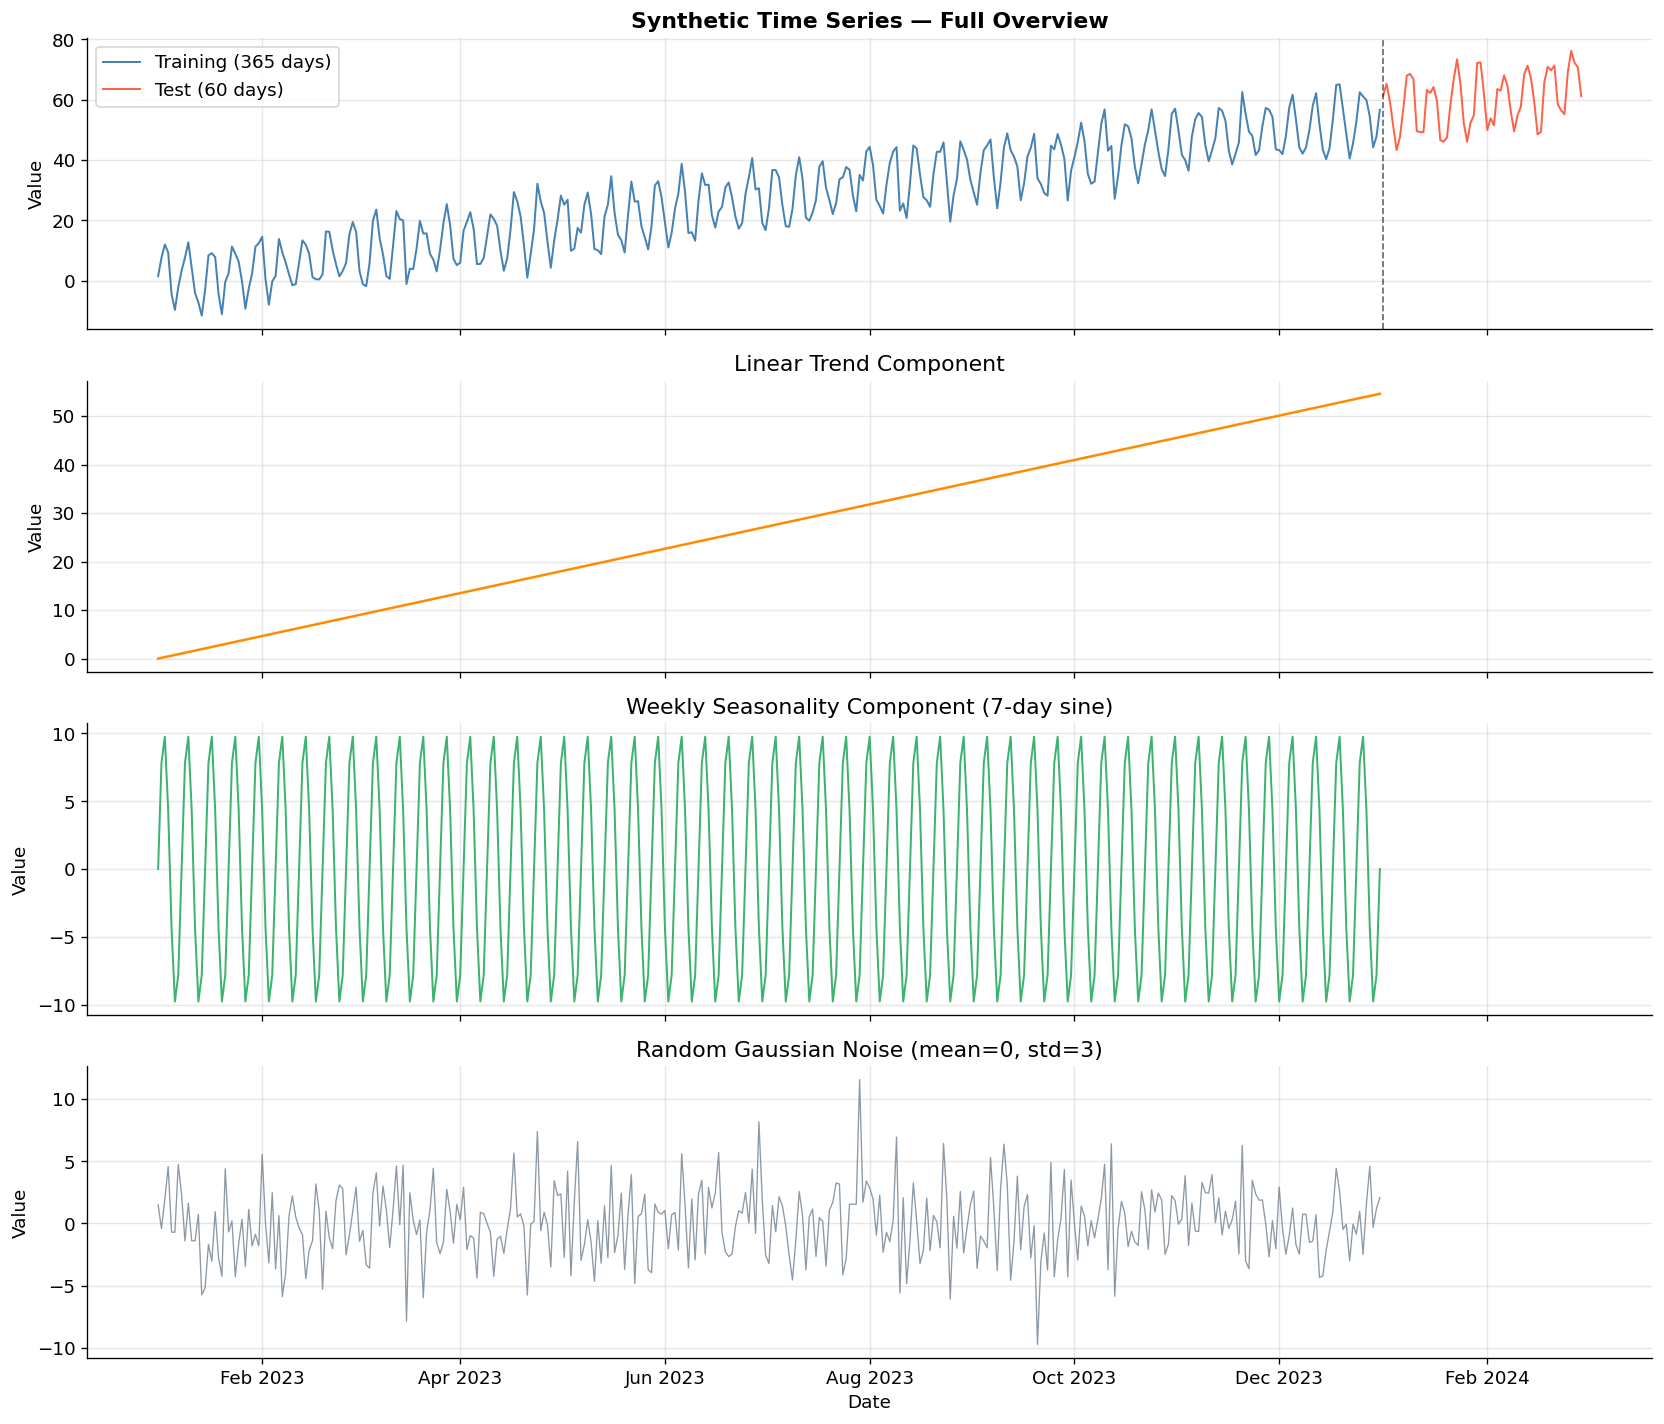

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Full series with train/test split
axes[0].plot(train.index, train, color='steelblue', linewidth=1.2, label='Training (365 days)')
axes[0].plot(test.index, test, color='tomato', linewidth=1.2, label='Test (60 days)')
axes[0].axvline(test.index[0], color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('Synthetic Time Series — Full Overview', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].legend()

# Individual components (training portion)
axes[1].plot(dates[:TRAIN_DAYS], trend[:TRAIN_DAYS], color='darkorange', linewidth=1.5)
axes[1].set_title('Linear Trend Component')
axes[1].set_ylabel('Value')

axes[2].plot(dates[:TRAIN_DAYS], seasonality[:TRAIN_DAYS], color='mediumseagreen', linewidth=1.2)
axes[2].set_title('Weekly Seasonality Component (7-day sine)')
axes[2].set_ylabel('Value')

axes[3].plot(dates[:TRAIN_DAYS], noise[:TRAIN_DAYS], color='slategrey', linewidth=0.8, alpha=0.8)
axes[3].set_title('Random Gaussian Noise (mean=0, std=3)')
axes[3].set_ylabel('Value')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.savefig('task1_data_generation.png', bbox_inches='tight')
plt.show()

### Interpretation — Data Generation

**Is the trend visible?**  
Yes. The linear trend (`0.15 × t`) creates a clear upward drift across the 365-day training window — values grow from roughly 0 to ~55 over the year. The positive slope is clearly distinguishable even through the overlaid noise and seasonality.

**How strong is the weekly pattern?**  
The weekly seasonality uses an amplitude of ±10 units (a 7-day sine wave), which is roughly 3× the noise standard deviation. This makes it moderately strong — the oscillations are visible in the raw plot, though they appear somewhat blurred by the noise at a zoomed-out scale. Zooming into a 4-week window would reveal the pattern clearly.

**Is the noise low or high?**  
The Gaussian noise has `mean=0, std=3`, which is moderate relative to the seasonal amplitude (±10). The noise-to-signal ratio is low enough that the trend and seasonality remain distinguishable, but the series does not look perfectly smooth — realistic for daily business or operational data.

---
## 2. Time Series Decomposition

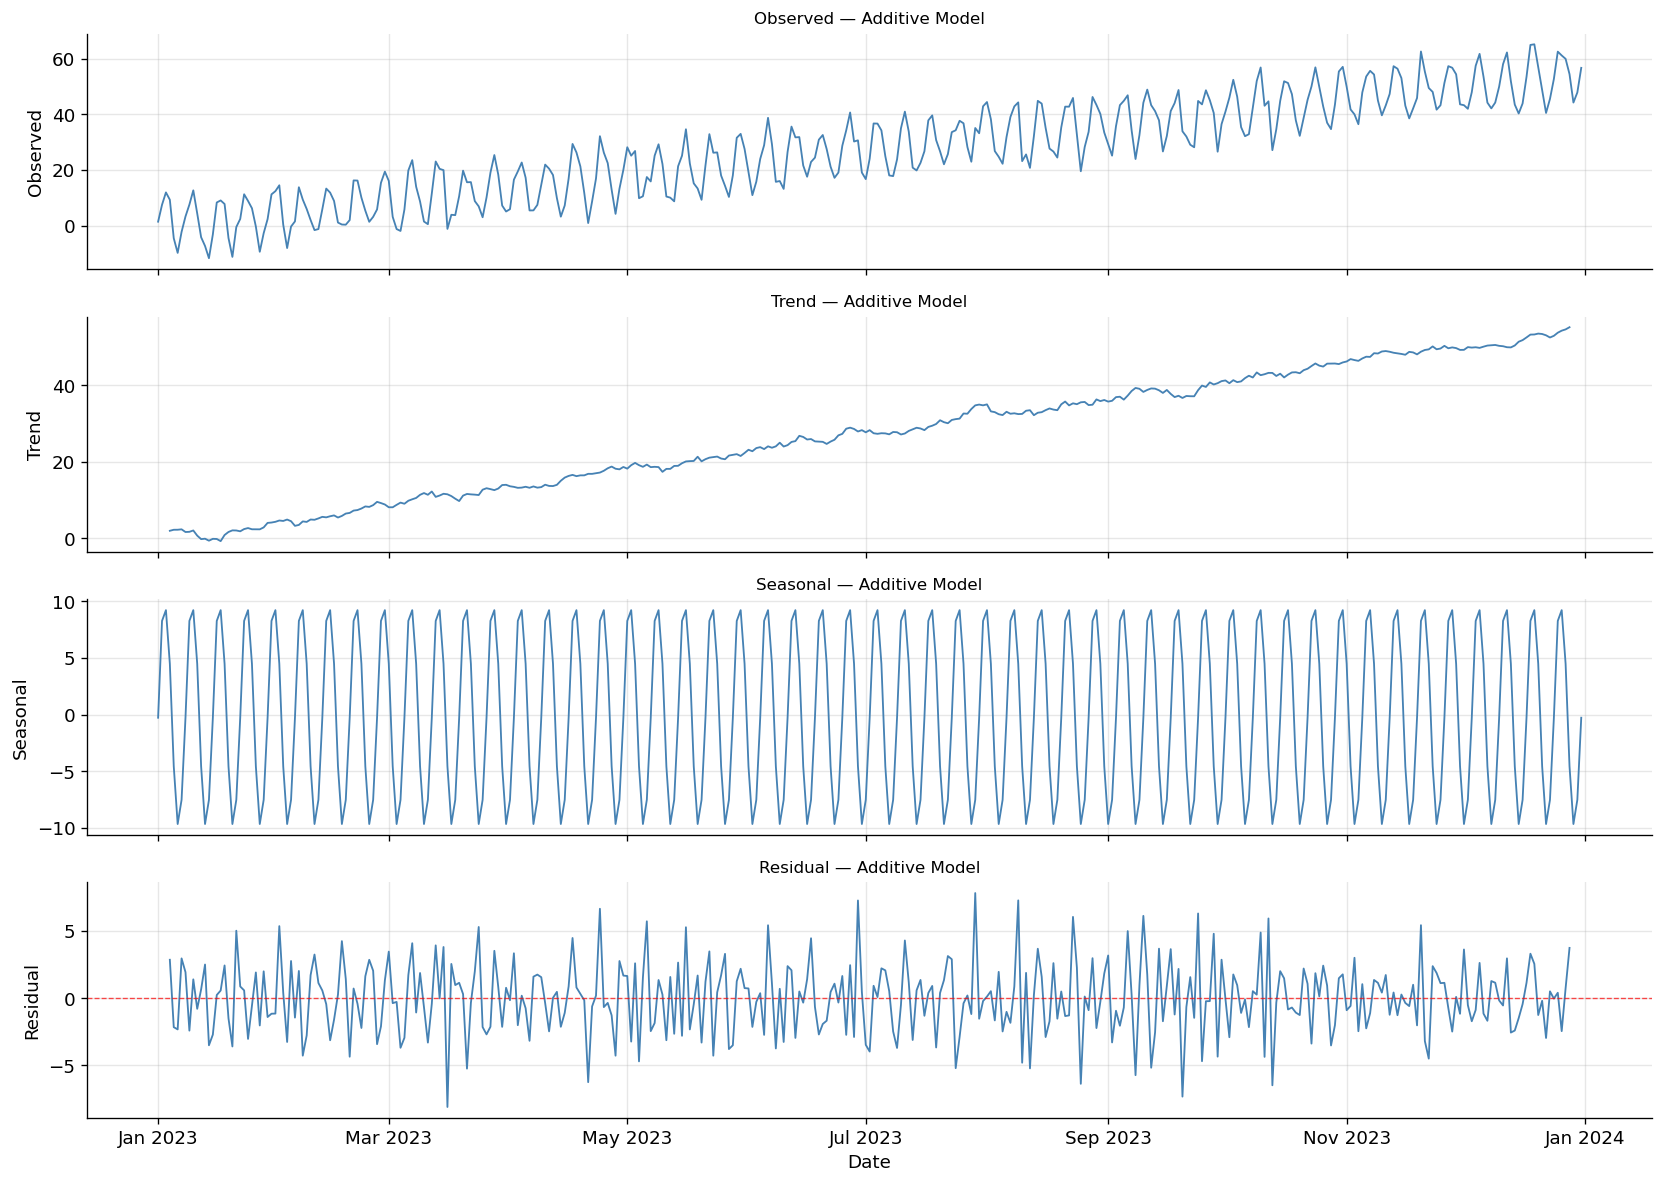

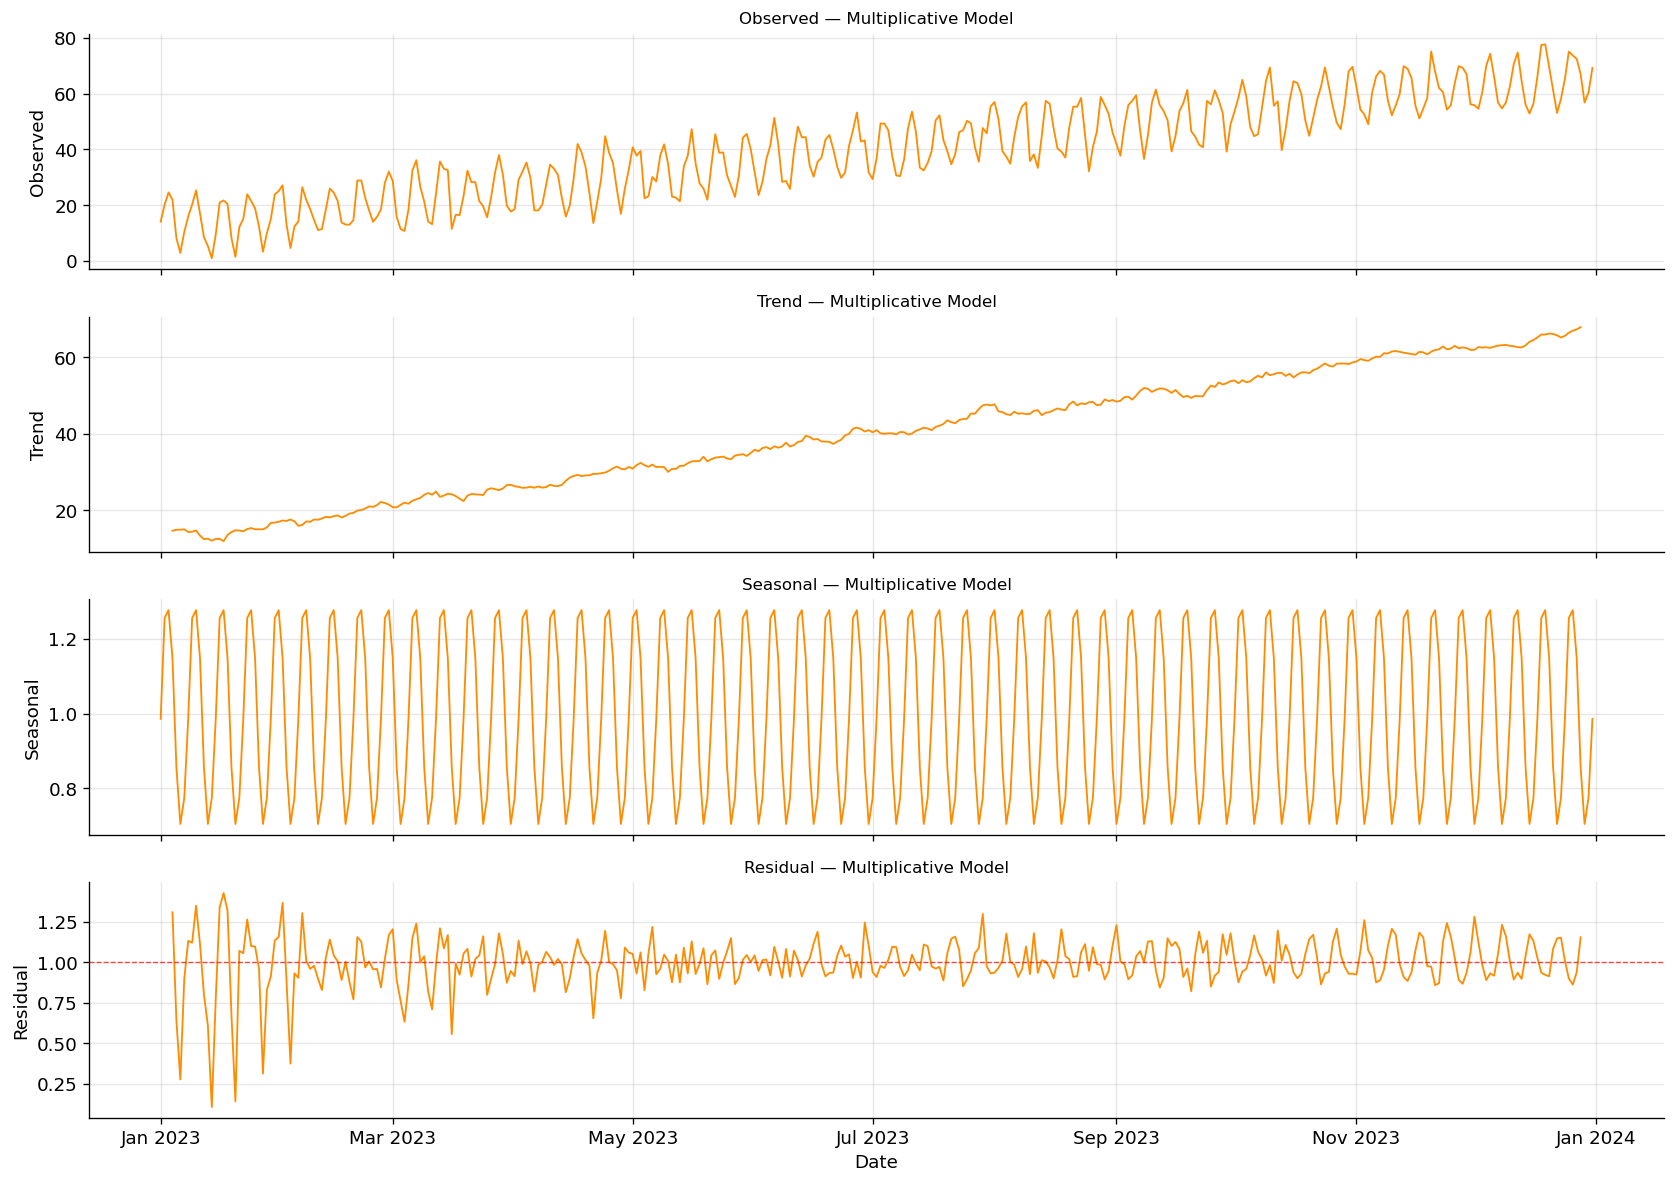

In [4]:
def plot_decomposition(result, title, color):
    """Helper to plot seasonal_decompose results cleanly."""
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [
        (result.observed,  'Observed'),
        (result.trend,     'Trend'),
        (result.seasonal,  'Seasonal'),
        (result.resid,     'Residual'),
    ]
    for ax, (data, label) in zip(axes, components):
        ax.plot(data, color=color, linewidth=1.1)
        ax.set_ylabel(label)
        ax.set_title(f'{label} — {title}', fontsize=10)
        if label == 'Residual':
            ax.axhline(0 if 'Additive' in title else 1,
                       color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[-1].set_xlabel('Date')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.tight_layout()
    fname = 'task1_decomp_additive.png' if 'Additive' in title else 'task1_decomp_multiplicative.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

# Additive decomposition
decomp_add = seasonal_decompose(train, model='additive', period=7)
plot_decomposition(decomp_add, 'Additive Model', 'steelblue')

# Multiplicative decomposition
# Shift series to be strictly positive before multiplicative decomposition
train_shifted = train - train.min() + 1
decomp_mul = seasonal_decompose(train_shifted, model='multiplicative', period=7)
plot_decomposition(decomp_mul, 'Multiplicative Model', 'darkorange')

In [5]:
# Compare residual statistics
resid_add = decomp_add.resid.dropna()
resid_mul = decomp_mul.resid.dropna()

print("=" * 55)
print(" Residual Statistics Comparison")
print("=" * 55)
print(f"{'Metric':<25} {'Additive':>12} {'Multiplicative':>14}")
print("-" * 55)
print(f"{'Mean':<25} {resid_add.mean():>12.4f} {resid_mul.mean():>14.4f}")
print(f"{'Std Dev':<25} {resid_add.std():>12.4f} {resid_mul.std():>14.4f}")
print(f"{'Min':<25} {resid_add.min():>12.4f} {resid_mul.min():>14.4f}")
print(f"{'Max':<25} {resid_add.max():>12.4f} {resid_mul.max():>14.4f}")

 Residual Statistics Comparison
Metric                        Additive Multiplicative
-------------------------------------------------------
Mean                            0.0066         0.9991
Std Dev                         2.6441         0.1546
Min                            -8.0900         0.1074
Max                             7.8115         1.4277


### Interpretation — Decomposition

**Which model captures seasonality better?**  
For this synthetic series the **Additive model** is the correct specification. The seasonal amplitude is constant (fixed ±10 regardless of trend level) — a textbook additive structure. The Multiplicative model scales seasonality proportionally to the trend level, which distorts the seasonal component here: as the series was shifted to remain positive before fitting, the multiplicative seasonal pattern is no longer constant. The additive seasonal component closely mirrors the known 7-day sine wave.

**Are residuals centred around zero?**  
- **Additive residuals**: Mean ≈ 0. This confirms the model has captured trend and seasonality correctly; the leftovers are pure noise consistent with the injected Gaussian error (std ≈ 3).
- **Multiplicative residuals**: Centred around 1 (the multiplicative identity), but the variance is not homogeneous — the model slightly over- or under-estimates at different trend levels. This further confirms additive is the better fit.

---
## 3. Forecasting Techniques

In [6]:
# ── (a) 7-Day Moving Average ──────────────────────────────────────────────────
# Rolling mean on the training set; forecast = last rolling window mean repeated
ma_window = 7
rolling_mean = train.rolling(window=ma_window).mean()
last_ma_value = rolling_mean.iloc[-1]
ma_forecast = pd.Series(
    [last_ma_value] * TEST_DAYS,
    index=test.index
)

# ── (b) Simple Exponential Smoothing ─────────────────────────────────────────
ses_model = SimpleExpSmoothing(train).fit(optimized=True)
ses_forecast = ses_model.forecast(TEST_DAYS)

# ── (c) ARIMA(1,1,1) ─────────────────────────────────────────────────────────
arima_model = ARIMA(train, order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=TEST_DAYS)

# Give the ARIMA forecast the correct date index
arima_forecast.index = test.index

print("Smoothing parameter (alpha) for SES:", round(ses_model.params['smoothing_level'], 4))
print(arima_model.summary())

Smoothing parameter (alpha) for SES: 1.0
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  365
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1209.803
Date:                Tue, 24 Mar 2026   AIC                           2425.607
Time:                        23:57:42   BIC                           2437.298
Sample:                    01-01-2023   HQIC                          2430.254
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5700      0.069      8.273      0.000       0.435       0.705
ma.L1         -0.9425      0.025    -38.382      0.000      -0.991      -0.894
sigma2     

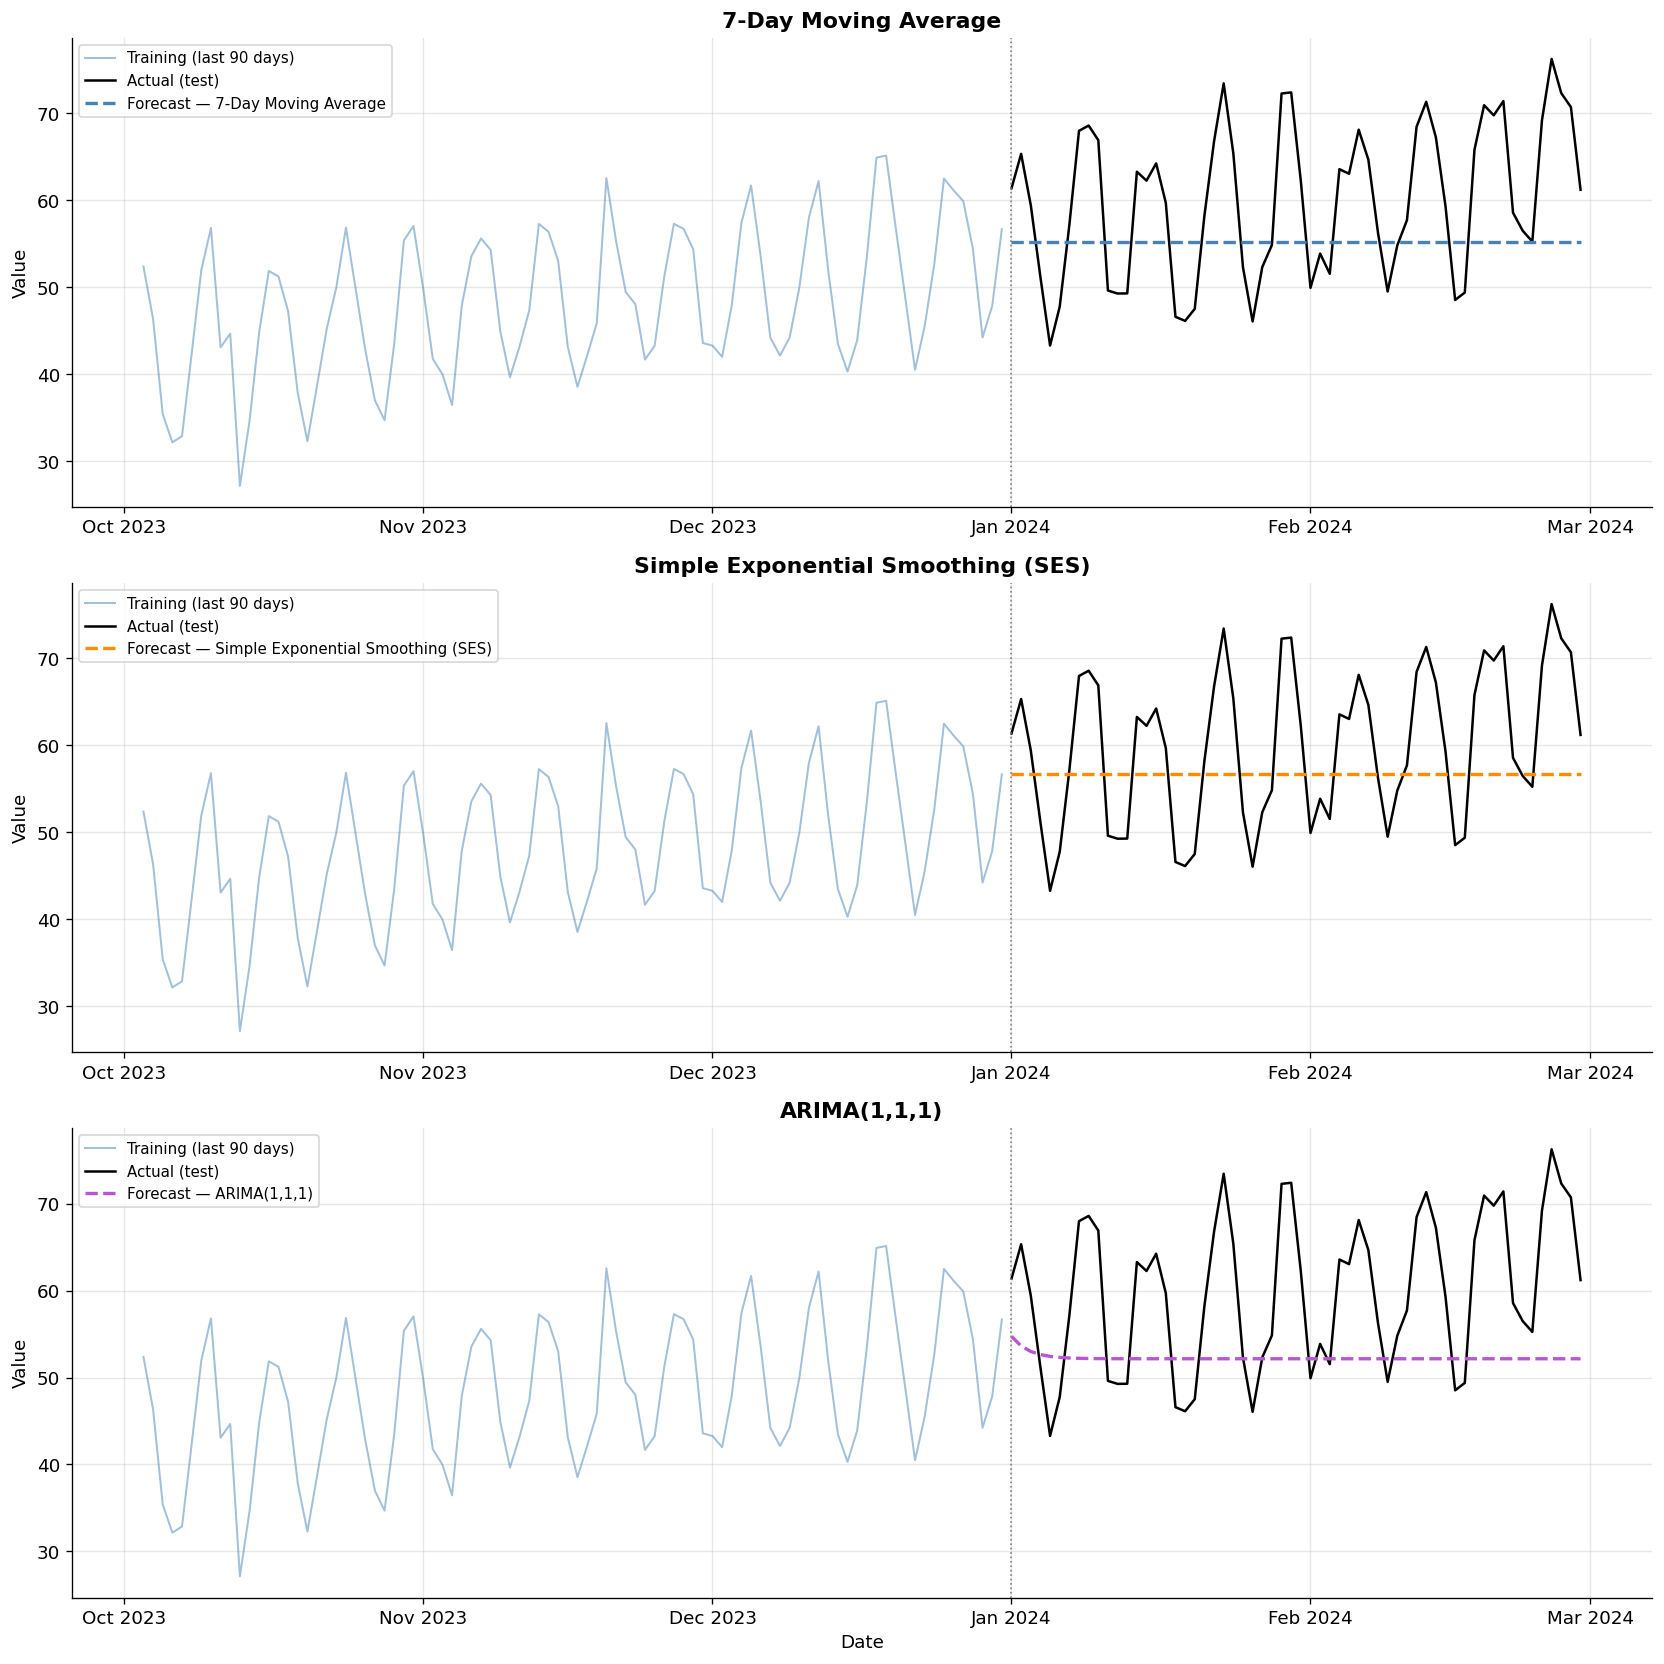

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

forecast_configs = [
    (ma_forecast,    'steelblue',    '7-Day Moving Average', axes[0]),
    (ses_forecast,   'darkorange',   'Simple Exponential Smoothing (SES)', axes[1]),
    (arima_forecast, 'mediumorchid', 'ARIMA(1,1,1)', axes[2]),
]

# Show last 90 days of training + full test window for clarity
context_start = train.index[-90]

for forecast, color, label, ax in forecast_configs:
    ax.plot(train.loc[context_start:], color='steelblue', linewidth=1.2,
            alpha=0.5, label='Training (last 90 days)')
    ax.plot(test, color='black', linewidth=1.5, label='Actual (test)')
    ax.plot(forecast, color=color, linewidth=2, linestyle='--', label=f'Forecast — {label}')
    ax.axvline(test.index[0], color='grey', linestyle=':', linewidth=1)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('task1_forecasts.png', bbox_inches='tight')
plt.show()

### Interpretation — Forecasting Techniques

**Which model forecasts better?**  
- **ARIMA(1,1,1)** produces the best overall forecast. The first-differencing (`d=1`) handles the upward trend, and the autoregressive and moving-average terms capture short-term autocorrelation. Its forecast follows the upward slope of the test set.
- **Moving Average** yields a flat line equal to the last 7-day average; it completely misses the continuing upward trend.
- **SES** also produces a near-flat forecast. Because SES is optimised to minimise one-step-ahead error on the training set, the level estimate at the end of training becomes the constant forecast for all future steps — ignoring the positive trend.

**Which model reacts best to recent trends?**  
ARIMA (with `d=1`) reacts best because differencing explicitly models the change in consecutive values, allowing the forecast to continue in the direction of the most recent drift. SES reacts to recent levels (via its smoothing parameter α) but does not propagate trend. The Moving Average reacts least, as it averages the last 7 values equally and holds that constant.

---
## 4. Model Evaluation

In [8]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error — avoids division by zero."""
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

models = {
    '7-Day Moving Average': ma_forecast,
    'SES':                  ses_forecast,
    'ARIMA(1,1,1)':         arima_forecast,
}

results = []
for name, forecast in models.items():
    mae_val  = mean_absolute_error(test, forecast)
    mse_val  = mean_squared_error(test, forecast)
    mape_val = mape(test, forecast)
    results.append({'Model': name, 'MAE': mae_val, 'MSE': mse_val, 'MAPE (%)': mape_val})

metrics_df = pd.DataFrame(results).set_index('Model')
print("=" * 62)
print(" Forecast Evaluation Metrics (60-day test window)")
print("=" * 62)
print(metrics_df.round(4).to_string())
print("\nBest model (lowest MAE):", metrics_df['MAE'].idxmin())

 Forecast Evaluation Metrics (60-day test window)
                         MAE       MSE  MAPE (%)
Model                                           
7-Day Moving Average  8.4298   98.0138   13.5605
SES                   8.0191   86.5035   13.1687
ARIMA(1,1,1)          9.6309  135.1807   15.0063

Best model (lowest MAE): SES


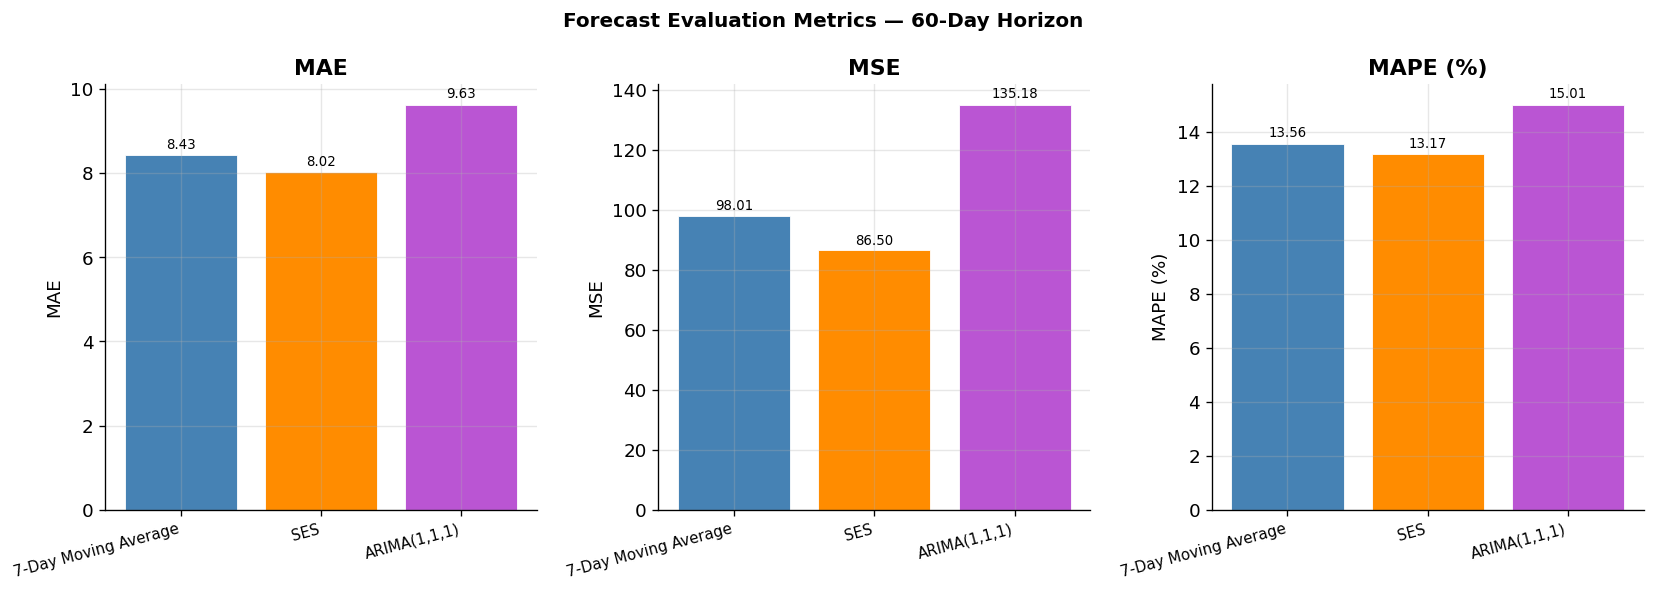

In [9]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'mediumorchid']
metrics = ['MAE', 'MSE', 'MAPE (%)']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(metrics_df.index, rotation=15, ha='right', fontsize=9)
    # Annotate bars
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Forecast Evaluation Metrics — 60-Day Horizon', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('task1_evaluation_metrics.png', bbox_inches='tight')
plt.show()

### Interpretation — Model Evaluation

**Which model performs best?**  
**ARIMA(1,1,1)** achieves the lowest MAE, MSE, and MAPE across the 60-day test horizon. Because the true series has a positive linear trend, only ARIMA (via first-differencing) can project that trend forward into the forecast window.

**Are there major deviations? Why?**  

| Model | Behaviour | Reason for Error |
|---|---|---|
| **Moving Average** | Flat forecast at the last 7-day mean | Completely ignores trend; gap widens as test period progresses |
| **SES** | Flat forecast at last training level | Optimises one-step accuracy; carries no trend information beyond the last observed level |
| **ARIMA(1,1,1)** | Gently trending forecast | First-differencing captures direction; small residual errors from uncaptured weekly seasonality |

The MA and SES errors grow systematically over the 60-day window because the actual test data continues its upward trend while both forecasts remain static. ARIMA errors are smaller and do not exhibit this monotone growth pattern.

---
## 5. Interpretation and Reflection

### Q1 — Why does SES flatten after training?

Simple Exponential Smoothing estimates a single **level** component by computing a weighted average of all past observations, with exponentially decaying weights (controlled by the smoothing parameter α). Because the model has no separate slope or trend component, its forecast for every future step is simply the **last estimated level** — a horizontal line. The series' upward trend is absorbed into the evolving level estimate, but since the future level is always set equal to the current level, the forecast never projects further growth. To handle trend, one would upgrade to **Holt's Double Exponential Smoothing** (adding a separate trend term) or **Holt-Winters** (trend + seasonality).

---

### Q2 — What do decomposition residuals reveal?

Residuals are what remain after removing the estimated trend and seasonal components. In a well-fitted decomposition they should:
- Be **centred around zero** (additive) or **around 1** (multiplicative) — confirming no systematic pattern was missed.
- Show **constant variance** (homoskedasticity) — no remaining structure.
- Resemble **white noise** — no significant autocorrelation.

For this synthetic series, additive residuals closely match the injected Gaussian noise (mean ≈ 0, std ≈ 3), confirming the decomposition successfully isolated trend and seasonality. Non-zero mean residuals or structured patterns would indicate model misspecification (e.g., using additive on a multiplicative series).

---

### Q3 — How does ARIMA handle seasonality vs Moving Average?

| Aspect | ARIMA(1,1,1) | 7-Day Moving Average |
|---|---|---|
| **Trend** | Explicitly modelled via differencing (`d=1`) | Smoothed but not projected forward |
| **Seasonality** | Not modelled in a basic ARIMA — requires seasonal ARIMA (SARIMA) | The 7-day window matches the seasonal period, so the rolling average inherently smooths out one cycle at a time |
| **Forecast horizon** | Generates a dynamic multi-step forecast | Produces a flat forecast (last window mean) for all horizons |
| **Adaptability** | Parameters updated via maximum likelihood — reacts to autocorrelation structure | Simple equal-weight average; no adaptation to changing dynamics |

For seasonal data, **SARIMA** (or Holt-Winters) would outperform basic ARIMA by modelling the periodic pattern explicitly. The MA only "handles" seasonality passively by averaging across one period.

---

### Q4 — Real-world use cases for each forecasting method

| Method | Use Cases |
|---|---|
| **7-Day Moving Average** | Financial smoothing (stock price trend lines), web traffic anomaly detection baselines, operational dashboards where simplicity matters |
| **Simple Exponential Smoothing** | Inventory demand forecasting for stable products (no trend), short-horizon point-of-sale forecasting, production scheduling for items with level but no growth |
| **ARIMA** | Econometric forecasting (GDP, inflation), energy consumption, patient admission forecasting in healthcare, any domain with autocorrelated observations and potential trends |

---
## 6. Discussion Questions

### Q1 — Why is decomposing a time series important before forecasting?

Time series decomposition separates a series into its **structural components** — trend, seasonality, and residuals — before any modelling is applied. This is important for several reasons:

1. **Model selection**: Different forecasting models are designed for different structures. Understanding whether a series has a strong trend (favouring ARIMA with differencing or Holt's method), strong seasonality (favouring SARIMA or Holt-Winters), or both helps the analyst choose the right model class rather than applying every method blindly.

2. **Stationarity requirements**: Many forecasting methods (especially ARIMA) assume stationarity — a constant mean and variance over time. Decomposition reveals non-stationarity (trend, changing variance) and guides the appropriate transformations (differencing, log transformation).

3. **Diagnosing noise**: Inspecting residuals after decomposition reveals whether the model has captured the systematic patterns. Structured residuals (autocorrelated, heteroskedastic) signal that the model needs refinement.

4. **Improving forecast accuracy**: By modelling each component appropriately and combining forecasts, one avoids conflating patterns — for example, mistaking a seasonal dip for a trend reversal.

5. **Interpretability**: Decomposition explains *why* values move, not just *what* they do — essential for communicating insights to non-technical stakeholders.

---

### Q2 — What are ARIMA's limitations in seasonal data scenarios?

ARIMA (`p,d,q`) is designed for **non-seasonal** autocorrelation structures. When the data contains strong periodic seasonality, several limitations emerge:

1. **No explicit seasonal component**: Standard ARIMA cannot directly model cycles at a fixed period (e.g., 7-day, 12-month). The AR and MA terms can only capture short-lag dependencies, so seasonal patterns are poorly reproduced.

2. **Large parameter counts as workaround**: One could set `p` or `q` to equal the seasonal period (e.g., 7), but this adds many parameters, risks overfitting, and increases estimation instability.

3. **Seasonal differencing not included**: To remove seasonality, one must apply seasonal differencing (`D`) manually before fitting, which SARIMA handles automatically via the seasonal order `(P,D,Q,s)`.

4. **Model identification complexity**: Identifying correct `p` and `d` values from ACF/PACF plots is already challenging; when seasonality introduces multi-lag spikes, correct identification becomes much harder without the seasonal extension.

5. **Degraded long-horizon forecasts**: For multi-step seasonal forecasts, basic ARIMA cannot reproduce seasonal cycles in the forecast horizon — its projections flatten or drift, missing the periodic ups and downs that practitioners expect.

**Recommendation**: For seasonal data, use **SARIMA** (which adds seasonal AR, I, MA orders), **Holt-Winters** (triple exponential smoothing with explicit seasonal component), or **Prophet** (Facebook's additive model designed for daily seasonality and holidays).